<a href="https://colab.research.google.com/github/KarenPachon/An-lisis-comparativo-de-las-proyecciones-poblacionales-del-DANE-/blob/main/Post_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalar R y paquetes necesarios en Colab
install.packages(
  c("googledrive","readxl","npregfast"),
  repos="https://cloud.r-project.org/",
  dependencies=TRUE)

library(readxl)
library(npregfast)
library(googledrive)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘hunspell’, ‘rex’, ‘iterators’, ‘spelling’, ‘covr’, ‘doParallel’, ‘foreach’, ‘sfsmisc’, ‘shinyjs’, ‘wesanderson’, ‘gridExtra’




# Carga y visualización de los datos

In [4]:
library(readxl)
PPED_AreaSexoEdadNac_2018_2070 <- read_excel(
  "/PPED-AreaSexoEdadNac-2018-2070PostCovid.xlsx",skip = 8)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`


In [8]:
pob_post <- data.frame(PPED_AreaSexoEdadNac_2018_2070) #Se crea un data.frame llamado poblacion pre a partir de los datos del DANE

In [9]:
head(pob_post)#Se muestra las primeras 6 filas
dim(pob_post) #Da el número de filas y columnas del data.frame

,...1,...2,...3,Total,Hombres,Mujeres,Hombres.0.años,Hombres.1.año,Hombres.2.años,Hombres.3.años,⋯,Total.91.años,Total.92.años,Total.93.años,Total.94.años,Total.95.años,Total.96.años,Total.97.años,Total.98.años,Total.99.años,Total.100.años..y.más
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Total Nacional,2018,Cabecera,36414521,17450356,18964165,267725,271659,275579,279172,⋯,24147,19263,15164,11854,9267,7131,5410,3899,2719,9450
2,Total Nacional,2018,Centros Poblados y Rural Disperso,11843973,6163808,5680165,111886,112733,114233,116189,⋯,6379,5039,3951,3061,2390,1830,1401,1035,765,2693
3,Total Nacional,2018,Total,48258494,23614164,24644330,379611,384392,389812,395361,⋯,30526,24302,19115,14915,11657,8961,6811,4934,3484,12143
4,Total Nacional,2019,Cabecera,37219289,17846792,19372497,267420,273412,276783,280107,⋯,25246,20298,15978,12403,9549,7365,5582,4184,2992,7181
5,Total Nacional,2019,Centros Poblados y Rural Disperso,12047237,6270851,5776386,112272,113270,114410,116137,⋯,6710,5315,4140,3200,2460,1893,1439,1100,814,2044
6,Total Nacional,2019,Total,49266526,24117643,25148883,379692,386682,391193,396244,⋯,31956,25613,20118,15603,12009,9258,7021,5284,3806,9225


[1] 127 309

Exploración de la columna 99

In [10]:
pob_post[, 99]
pob_post[5:109,100]

[1]  6944  2344  9288  7303  2447  9750  7707  2565 10272  7697  2560 10257
 [13]  7523  2503 10026  7545  2515 10060  7739  2569 10308  7964  2646 10610
 [25]  8139  2668 10807  8354  2720 11074  8614  2806 11420  9005  2941 11946
 [37]  9424  3068 12492  9782  3144 12926 10101  3196 13297 10410  3245 13655
 [49] 10707  3284 13991 11028  3334 14362 11450  3391 14841 12024  3521 15545
 [61] 12704  3674 16378 13516  3858 17374 14300  4034 18334 15086  4188 19274
 [73] 15891  4345 20236 16761  4526 21287 17635  4697 22332 18585  4868 23453
 [85] 19592  5045 24637 20607  5241 25848 21604  5412 27016 22784  5642 28426
 [97] 23923  5867 29790 31359 32981 34837 36595 38211 39622 40841 41862 42950
[109] 43693 44672 45314 45910 46471 47233 48149 49297 50986 53470 55765    NA
[121]    NA    NA    NA    NA    NA    NA    NA

[1]  1901  7624  6051  1983  8034  6114  2022  8136  6042  1997  8039  6006
 [13]  1970  7976  6188  2031  8219  6354  2080  8434  6544  2135  8679  6694
 [25]  2157  8851  6881  2207  9088  7104  2275  9379  7430  2392  9822  7790
 [37]  2498 10288  8095  2567 10662  8380  2602 10982  8641  2651 11292  8903
 [49]  2678 11581  9183  2722 11905  9548  2773 12321 10040  2880 12920 10619
 [61]  3011 13630 11309  3163 14472 11980  3311 15291 12659  3441 16100 13344
 [73]  3573 16917 14096  3725 17821 14847  3866 18713 15664  4013 19677 16530
 [85]  4162 20692 17421  4311 21732 18263  4472 22735 19282  4664 23946 25114
 [97] 26469 27865 29459 30978 32374 33598 34663 35559 36510

# Filtrado y reestructuración de los datos

In [11]:
base_NacPost = data.frame(pob_post[2:119, ])#Se crea un nuevo data.frame con las filas 3 a 159,eliminando filas que no contienen datos útiles
head(base_NacPost)

,...1,...2,...3,Total,Hombres,Mujeres,Hombres.0.años,Hombres.1.año,Hombres.2.años,Hombres.3.años,⋯,Total.91.años,Total.92.años,Total.93.años,Total.94.años,Total.95.años,Total.96.años,Total.97.años,Total.98.años,Total.99.años,Total.100.años..y.más
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,Total Nacional,2018,Centros Poblados y Rural Disperso,11843973,6163808,5680165,111886,112733,114233,116189,⋯,6379,5039,3951,3061,2390,1830,1401,1035,765,2693
3,Total Nacional,2018,Total,48258494,23614164,24644330,379611,384392,389812,395361,⋯,30526,24302,19115,14915,11657,8961,6811,4934,3484,12143
4,Total Nacional,2019,Cabecera,37219289,17846792,19372497,267420,273412,276783,280107,⋯,25246,20298,15978,12403,9549,7365,5582,4184,2992,7181
5,Total Nacional,2019,Centros Poblados y Rural Disperso,12047237,6270851,5776386,112272,113270,114410,116137,⋯,6710,5315,4140,3200,2460,1893,1439,1100,814,2044
6,Total Nacional,2019,Total,49266526,24117643,25148883,379692,386682,391193,396244,⋯,31956,25613,20118,15603,12009,9258,7021,5284,3806,9225
7,Total Nacional,2020,Cabecera,38130362,18296255,19834107,272089,274272,279600,282319,⋯,25941,21306,16913,13120,10063,7644,5822,4363,3245,6101


# Suma de la población total para cada año

In [12]:
proy_NacPost = data.frame(base_NacPost$...2,base_NacPost$...3, base_NacPost$Hombres,
                                 base_NacPost$Mujeres,base_NacPost$Total)
head(proy_NacPost)
proy_NacPost2=NULL #Crea un vector vacío.
proy_NacPost2[1]=sum(as.numeric(proy_NacPost[which((
  proy_NacPost$base_NacPost....2 == 2018)& ( proy_NacPost$base_NacPost....3=="Total")),5]))

for (i in 1:52){
  proy_NacPost2[i]= sum(as.numeric(proy_NacPost[which((
    proy_NacPost$base_NacPost....2 == 2017+i)&( proy_NacPost$base_NacPost....3=="Total")),5]))
}

,base_NacPost....2,base_NacPost....3,base_NacPost.Hombres,base_NacPost.Mujeres,base_NacPost.Total
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,2018,Centros Poblados y Rural Disperso,6163808,5680165,11843973
2,2018,Total,23614164,24644330,48258494
3,2019,Cabecera,17846792,19372497,37219289
4,2019,Centros Poblados y Rural Disperso,6270851,5776386,12047237
5,2019,Total,24117643,25148883,49266526
6,2020,Cabecera,18296255,19834107,38130362


# Gráfico de la proyección
Hace un gráfico de puntos de la proyección total de la población de comobia entre
2019 y 2070, en color rojo.

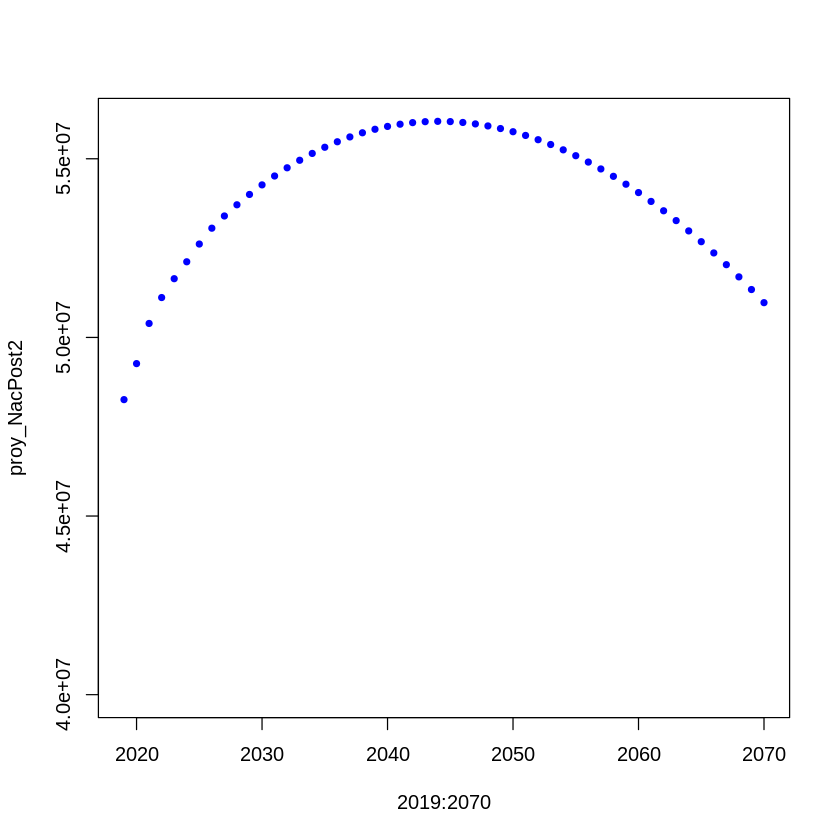

In [13]:
plot(2019:2070,proy_NacPost2, type="p",col="blue",pch=20, ylim = c(40000000, max(proy_NacPost2)))

# Construcción del vector con datos faltantes

1. Se crea un vector llamado
proyeccion nacionar Pre covid que simula datos semanales con muchos
NA y solo unos pocos valores observados de población anual. Estos valores los
vamos a imputar
2. Por cada año se colocan NA + un valor observado de población (por ejemplo,
después de 51 NA, el valor de 2018).
3. Esto da un vector más largo con solo 7 valores observados (uno por año).

In [14]:
proy_NacPost2[1]

poblacionPost_NA = c(
  rep(NA, 51), proy_NacPost2[1],  # 2018
  rep(NA, 51), proy_NacPost2[2],  # 2019
  rep(NA, 51), proy_NacPost2[3],  # 2020
  rep(NA, 51), proy_NacPost2[4],  # 2021
  rep(NA, 51), proy_NacPost2[5],  # 2022
  rep(NA, 51), proy_NacPost2[6],  # 2023
  rep(NA, 51), proy_NacPost2[7]  # 2024
)
length(poblacionPost_NA) #Muestra la longitud total del vector (debería ser 365, simulando un año completo).

[1] 48258494

[1] 364

Gráfico preliminar

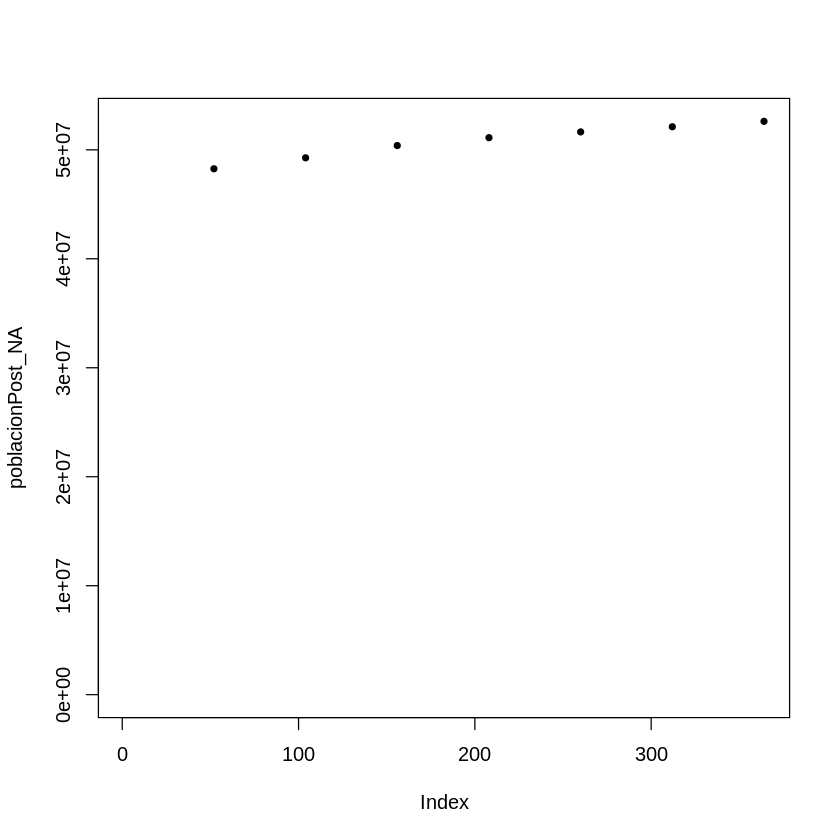

In [15]:
plot(poblacionPost_NA, pch = 20, ylim = c(0, max(na.omit(poblacionPost_NA))))
#Se grafica el vector de población, mostrando los puntos observados y muchos vacíos.

# Preparar datos para regresión no paramétrica

In [16]:
datos_finales2 = data.frame(año = (2018:2024), poblacion =
                             proy_NacPost2[1:7])
datos_finales2

#Regresión no paramétrica con frfast
regresion_Post = frfast(datos_finales2[, 2] ~ datos_finales2[, 1], model =
                        "np",
                      p = 3, smooth = "kernel", kbin = (364-51))
#Extraer e imputar los valores suavizados
imputacion_Post = data.frame(regresion_Post$p)

año,poblacion
<int>,<dbl>
2018,48258494
2019,49266526
2020,50390790
2021,51115637
2022,51643565
2023,52117067
2024,52613753


Gráfico con valores imputados

Se grafica:

* Los puntos observados reales
en color orquídea.
* La línea suavizada (modelo) en color azul cielo, representando la
interpolación de los valores faltantes. Acá tenemos los datos imputados para
cada semana.

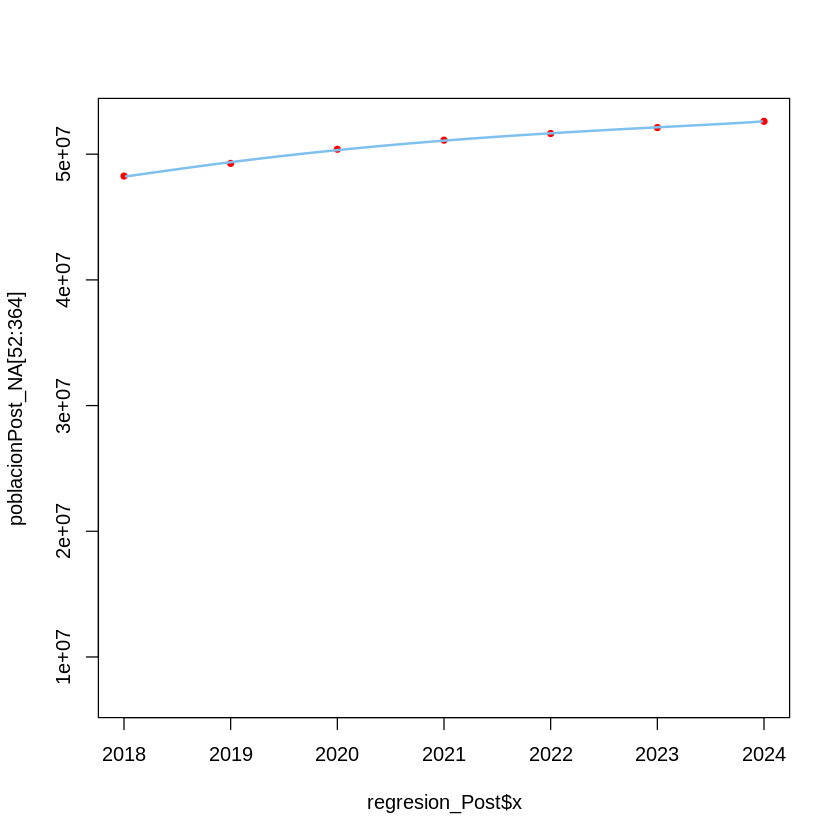

In [17]:
plot(regresion_Post$x, poblacionPost_NA[52:364], pch = 20,
     ylim = c(7000000, max(na.omit(poblacionPost_NA))), col = "red")

lines(regresion_Post$x, imputacion_Post$X1, lwd = 2, col = "skyblue2")

# Crear una secuencia de fechas semanales
Esto permite ver cómo cambia la población semana a semana entre 2018 y 2024

In [18]:
fechas2 = seq(as.Date("2018-12-30"), as.Date("2024-12-28"), by = "week")
imputacion_Post$X1[which(fechas2 == as.Date("2023-04-23"))]

[1] 51828032

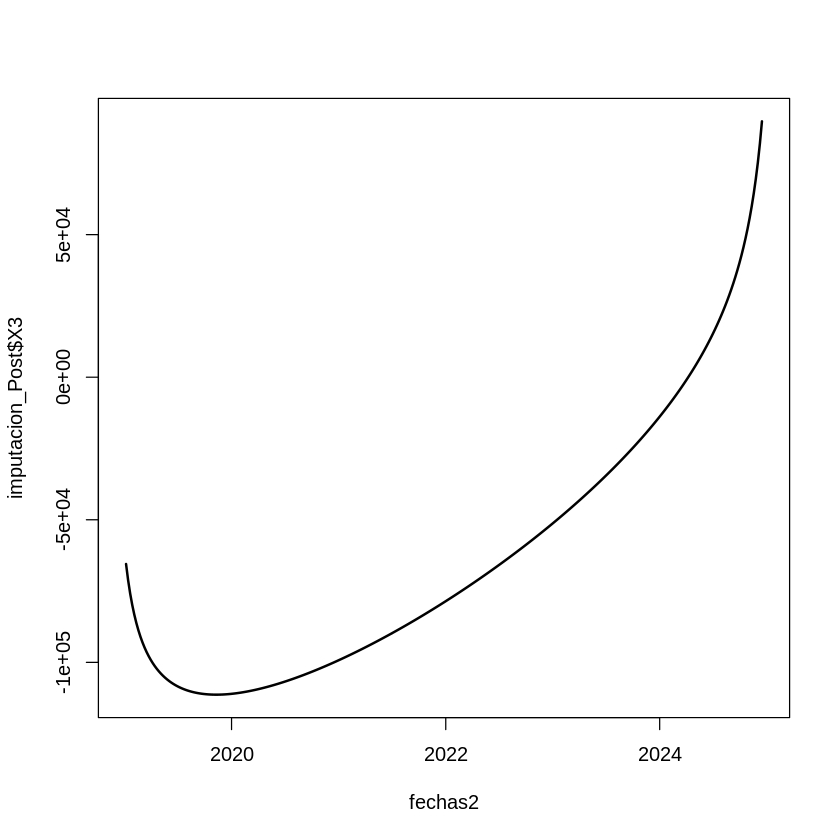

In [19]:
plot(fechas2, imputacion_Post$X3, lwd = 2, type = "l")

# Extraer un valor puntual de población imputada para una fecha específica

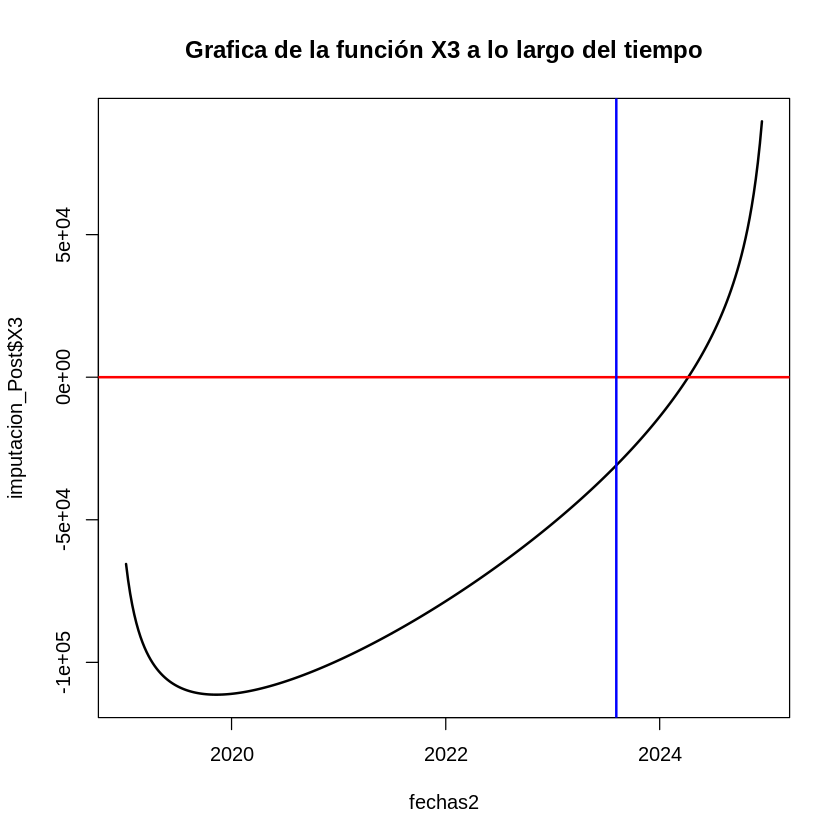

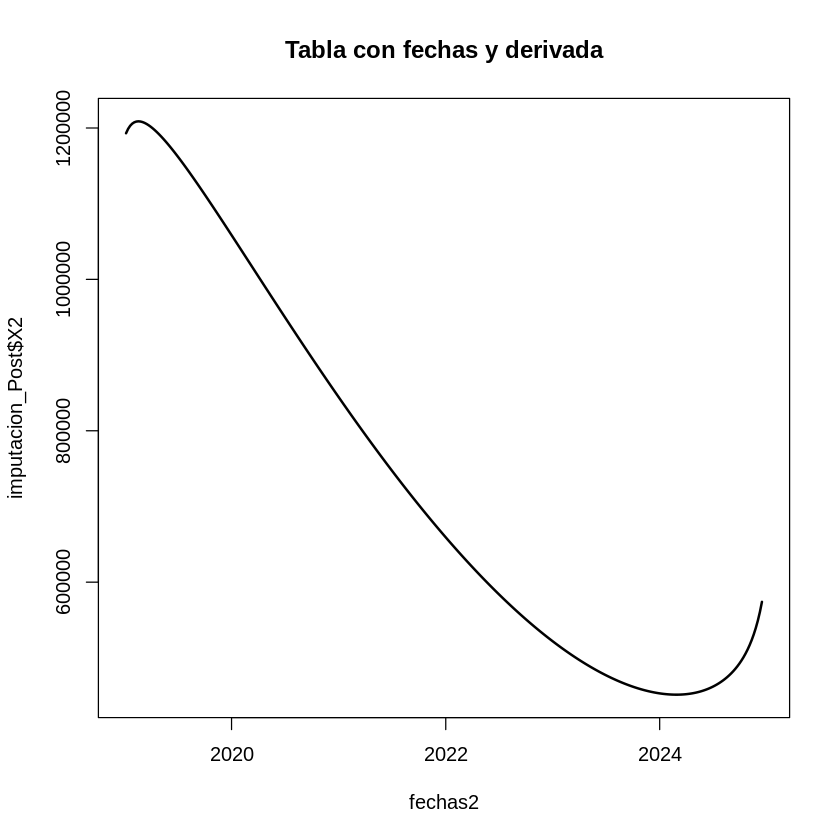

In [22]:
plot(fechas2, imputacion_Post$X3,
     main = "Grafica de la función X3 a lo largo del tiempo",
     lwd = 2, type = "l")

abline(h = 0, lwd = 2, col = "red")
abline(v = as.Date("2023-08-06"), lwd = 2, col = "blue")


tab_post=data.frame(fechas2, imputacion_Post$X3)
plot(fechas2, imputacion_Post$X2,
     main = "Tabla con fechas y derivada",
     lwd = 2, type = "l")

Se grafica la serie suavizada para visualizar cómo se comporta la población en el tiempo.
Esto ayuda a ver si una curva Gompertz puede ajustarse bien.

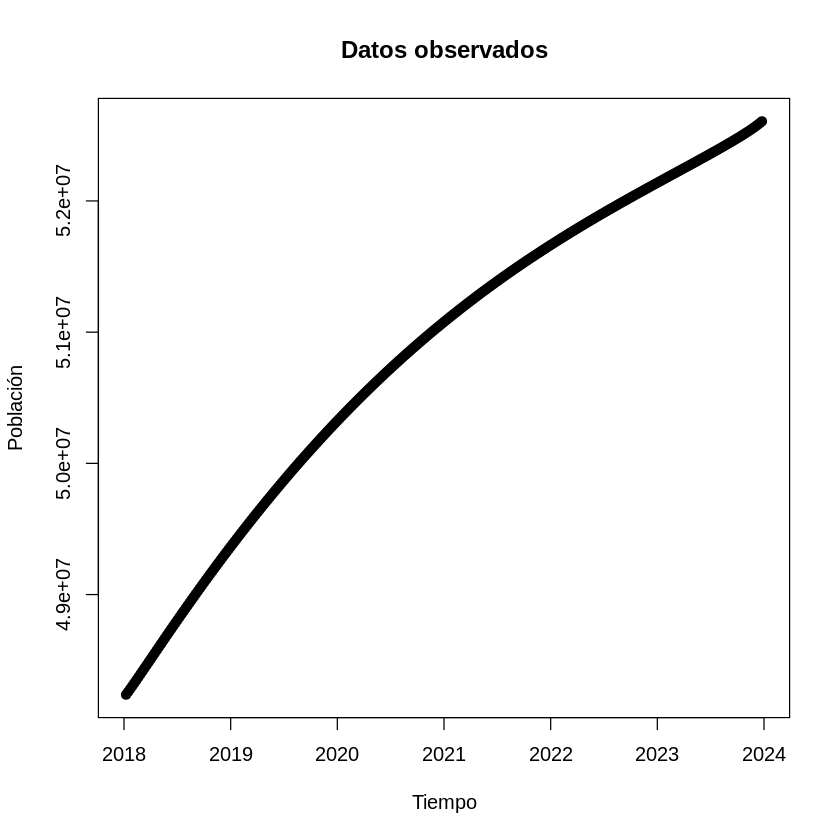

In [23]:
x_post <- regresion_Post$x # Tiempo (ej. años como fracción)
y_post <- imputacion_Post$X1 # Población imputada suavizada
plot(x_post, y_post, main = "Datos observados",
     xlab = "Tiempo", ylab = "Población", pch = 19)

# Inicializar parámetros de los modelos  
Estos valores son solo una referencia. En realidad, se usarán otros valores como *start* en el ajuste.

In [24]:
A_post <- max(na.omit(imputacion_Post$X1))/10000000 # Asíntota superior (capacidad máxima esperada)
B_post <- 0.11 # Desplazamiento horizontal (ligado al punto deinflexión)
C_post <- 0.05 # Tasa de crecimiento

datos <- na.omit(data.frame(x_post, y_post))

x1 <- (datos$x_post - 2018)[1:311]
y1 <- (datos$y_post / 10000000)
length(x1)
length(y1)

[1] 311

[1] 311

## Modelo Gompertz

In [25]:
gompertzModel_Post <- nls(
  y1 ~ A * exp(-B * exp(-C * x1)),
  start = list(A = 6, B = B_post, C = 0.05), # valores iniciales razonables
  control = list(maxiter = 500)
)
gompertzModel_Post

Nonlinear regression model
  model: y1 ~ A * exp(-B * exp(-C * x1))
   data: parent.frame()
     A      B      C 
5.3985 0.1134 0.2383 
 residual sum-of-squares: 0.000657

Number of iterations to convergence: 9 
Achieved convergence tolerance: 2.719e-06

In [26]:
summary(gompertzModel_Post)


Formula: y1 ~ A * exp(-B * exp(-C * x1))

Parameters:
   Estimate Std. Error t value Pr(>|t|)    
A 5.3984983  0.0012176  4433.8   <2e-16 ***
B 0.1134305  0.0001933   586.9   <2e-16 ***
C 0.2383063  0.0009107   261.7   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.001461 on 308 degrees of freedom

Number of iterations to convergence: 9 
Achieved convergence tolerance: 2.719e-06


In [34]:
confint(gompertzModel_Post)

Waiting for profiling to be done...



,2.5%,97.5%
A,5.3961095,5.4009222
B,0.1130516,0.1138151
C,0.2365068,0.2401069


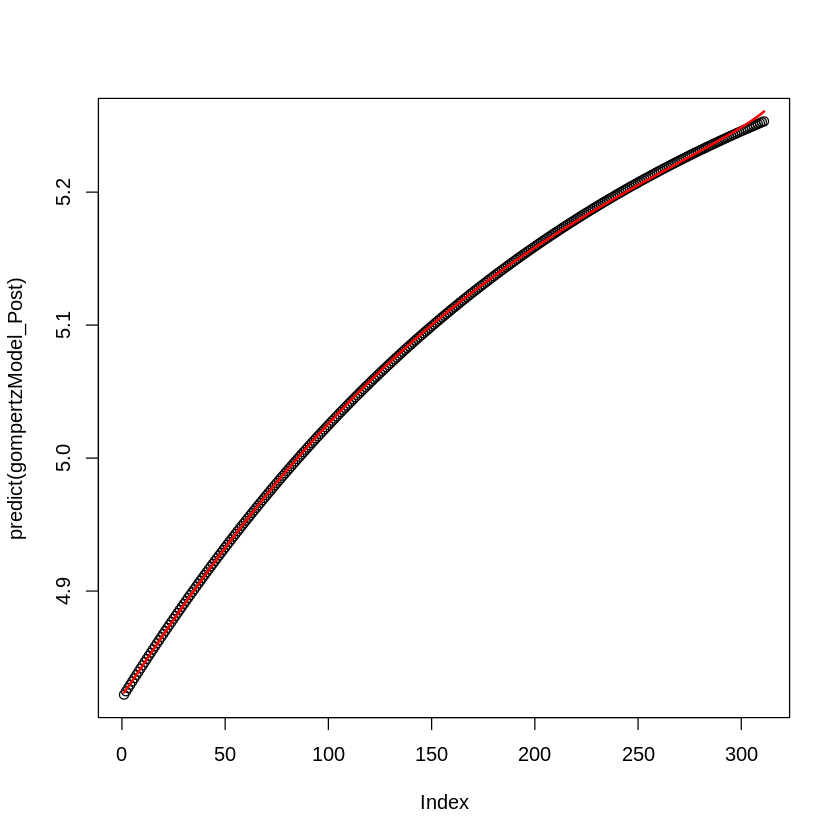

In [27]:
plot(predict(gompertzModel_Post))
lines(y1, lwd = 2, col = "red")

## Modelo Logistico

In [29]:
modelo_logistico <- nls(y1 ~ a / (1 + b * exp(-c * x1)),
                        start = list(a = A_post, b = B_post, c = 0.2))

summary(modelo_logistico)


Formula: y1 ~ a/(1 + b * exp(-c * x1))

Parameters:
   Estimate Std. Error t value Pr(>|t|)    
a 5.3894368  0.0012095  4455.8   <2e-16 ***
b 0.1181132  0.0002138   552.6   <2e-16 ***
c 0.2531384  0.0009664   261.9   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.001542 on 308 degrees of freedom

Number of iterations to convergence: 4 
Achieved convergence tolerance: 6.437e-07


In [35]:
confint(modelo_logistico)

Waiting for profiling to be done...



,2.5%,97.5%
a,5.3870619,5.3918474
b,0.1176939,0.1185390
c,0.2512270,0.2550512


## Modelo Richards

In [30]:
# Ajuste de Richards
# Ecuación: y = a / (1 + b * exp(-c * x1))^(1/m)
modelo_richards <- nls(
  y1 ~ a / (1 + b * exp(-c * x1))^(1/m),
  start = list(a = A_post, b = B_post, c = 0.2, m = 0.5),
  algorithm = "port",
  lower = c(1, 0.001, 0.001, 0.01),
  upper = c(Inf, Inf, Inf, 6.5),
  control = list(maxiter = 1000, minFactor = 1/2048)
)

summary(modelo_richards)


Formula: y1 ~ a/(1 + b * exp(-c * x1))^(1/m)

Parameters:
  Estimate Std. Error  t value Pr(>|t|)    
a 5.398404   0.002628 2054.407   <2e-16 ***
b 0.001135   0.027094    0.042    0.967    
c 0.238455   0.003717   64.155   <2e-16 ***
m 0.010000   0.238665    0.042    0.967    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.001464 on 307 degrees of freedom

Algorithm "port", convergence message: both X-convergence and relative convergence (5)


In [36]:
confint(modelo_richards)

Waiting for profiling to be done...



,2.5%,97.5%
a,NA,5.40083119
b,0.02343803,0.02529412
c,0.23665114,NA
m,NA,0.13135289


# Tabla comparativa de los tres modelos

In [31]:
# 1. Definir los años de interés (cada 5 años)
años_base <- seq(2018, 2068, by = 5)

# 2. Agregar manualmente el año 2070 al final
años_proyeccion <- c(años_base, 2070)

# 2. Convertirlos a la escala x1 del modelo (donde 2018 = 0)
x1_futuro <- data.frame(x1 = años_proyeccion - 2018)

# 3. Generar las predicciones (recordando que están en escala de millones)
pred_gompertz <- predict(gompertzModel_Post, newdata = x1_futuro)
pred_logistico <- predict(modelo_logistico, newdata = x1_futuro)
pred_richards  <- predict(modelo_richards, newdata = x1_futuro)

# 4. Crear la tabla comparativa (multiplicamos por 10 para volver a la escala real si es necesario)
tabla_proyecciones <- data.frame(
  Año = años_proyeccion,
  Gompertz_Millones = round(pred_gompertz, 5),
  Logistico_Millones = round(pred_logistico, 5),
  Richards_Millones = round(pred_richards, 5)
)

print(tabla_proyecciones)

    Año Gompertz_Millones Logistico_Millones Richards_Millones
1  2018           4.81960            4.82012           4.81960
2  2023           5.21566            5.21569           5.21566
3  2028           5.34229            5.33927           5.34226
4  2033           5.38136            5.37519           5.38130
5  2038           5.39329            5.38541           5.39321
6  2043           5.39691            5.38830           5.39683
7  2048           5.39802            5.38912           5.39792
8  2053           5.39835            5.38935           5.39826
9  2058           5.39845            5.38941           5.39836
10 2063           5.39848            5.38943           5.39839
11 2068           5.39849            5.38943           5.39840
12 2070           5.39850            5.38944           5.39840


## Grafico de la tabla comparativa

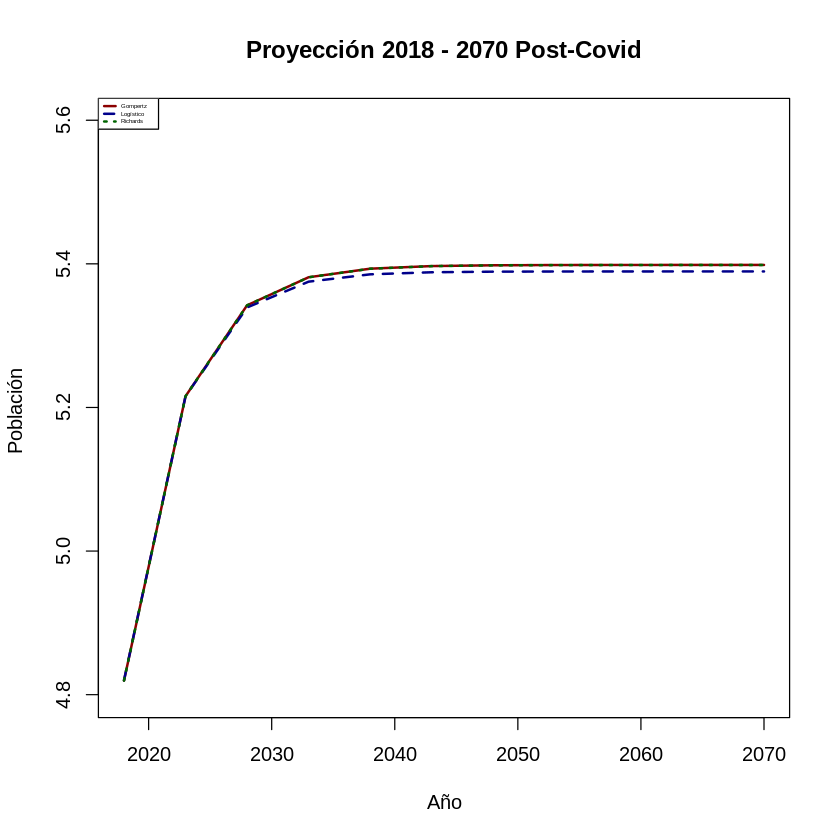

In [33]:
# Ahora ejecuta tu código de plot
plot(años_proyeccion, pred_richards, type = "n",
     main = "Proyección 2018 - 2070 Post-Covid",
     xlab = "Año", ylab = "Población ",
     ylim = c(4.8, max(pred_gompertz)+0.2))

# Añadir las líneas y la leyenda
lines(años_proyeccion, pred_gompertz, col = "darkred", lwd = 2)
lines(años_proyeccion, pred_logistico, col = "darkblue", lwd = 2, lty = 2)
lines(años_proyeccion, pred_richards, col = "darkgreen", lwd = 2, lty = 3)
legend("topleft", legend = c("Gompertz", "Logístico", "Richards"),
     col = c("darkred", "darkblue", "darkgreen"), lty = 1:3, lwd = 2, cex = 0.3)